# Monte Carlo Pricing & Physical Intuition

The option price is the **area under a curve** — the contribution curve:
$$C = \int_0^{\infty} \underbrace{\max(S_T - K, 0)}_{\text{payoff}} \cdot \underbrace{e^{-rT}\,f_{\mathbb{Q}}(S_T)}_{\text{discounted density}}\, dS_T$$

Monte Carlo pricing is just numerically approximating this integral by sampling.
This notebook:
1. Implements plain and antithetic Monte Carlo
2. Studies convergence ($1/\sqrt{N}$ rate)
3. Builds the **four-panel visualization** that makes the integral visible

In [1]:
import numpy as np
from scipy.stats import norm, lognorm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

rng = np.random.default_rng(42)

# np.trapz was renamed to np.trapezoid in NumPy 2.0
trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

def bs_call(S, K, T, r, q, sigma):
    """Black-Scholes call price."""
    if T <= 0:
        return float(max(S - K, 0.0))
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return float(S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2))

def bs_put(S, K, T, r, q, sigma):
    """Black-Scholes put price."""
    if T <= 0:
        return float(max(K - S, 0.0))
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return float(K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1))

# Reference parameters
S0, K, T, r, q, sigma = 100.0, 100.0, 1.0, 0.05, 0.02, 0.20

exact_call = bs_call(S0, K, T, r, q, sigma)
exact_put  = bs_put(S0, K, T, r, q, sigma)
print(f'Exact call: {exact_call:.4f}')
print(f'Exact put:  {exact_put:.4f}')

Exact call: 9.2270
Exact put:  6.3301


## 1. Monte Carlo Pricing

**Plain MC:** draw $N$ independent standard normals, compute $S_T^{(i)}$, average the discounted payoffs.

**Antithetic variates:** for each $Z$, also use $-Z$. The pair $(Z, -Z)$ are negatively correlated,
so their payoff average has lower variance. Same number of function evaluations, roughly half the variance.

In [5]:
def mc_call_plain(S0, K, T, r, q, sigma, N):
    """Plain Monte Carlo call price. Returns (price, std_error)."""
    Z   = rng.standard_normal(N)
    S_T = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    disc_payoffs = np.exp(-r*T) * np.maximum(S_T - K, 0.0)
    return disc_payoffs.mean(), disc_payoffs.std() / np.sqrt(N)

def mc_call_antithetic(S0, K, T, r, q, sigma, N):
    """Antithetic variate MC call price. N must be even."""
    N2  = N // 2
    Z   = rng.standard_normal(N2)
    fwd = (r - q - 0.5*sigma**2)*T
    S_p = S0 * np.exp(fwd + sigma*np.sqrt(T)*Z)
    S_n = S0 * np.exp(fwd - sigma*np.sqrt(T)*Z)
    pairs = 0.5 * (np.maximum(S_p - K, 0.0) + np.maximum(S_n - K, 0.0))
    disc_payoffs = np.exp(-r*T) * pairs
    return disc_payoffs.mean(), disc_payoffs.std() / np.sqrt(N2)

N = 50_000
price_plain,  se_plain  = mc_call_plain(S0, K, T, r, q, sigma, N)
price_antith, se_antith = mc_call_antithetic(S0, K, T, r, q, sigma, N)

print(f'Exact:          {exact_call:.4f}')
print(f'Plain MC:       {price_plain:.4f}  \u00b1{1.96*se_plain:.4f}  (95% CI)')
print(f'Antithetic MC:  {price_antith:.4f}  \u00b1{1.96*se_antith:.4f}  (95% CI)')
print(f'\nVariance reduction from antithetic: {(se_plain/se_antith)**2:.1f}x')

Exact:          9.2270
Plain MC:       9.2613  ±0.1221  (95% CI)
Antithetic MC:  9.1794  ±0.0893  (95% CI)

Variance reduction from antithetic: 1.9x


## 2. Convergence

The MC error scales as $1/\sqrt{N}$ (central limit theorem). Antithetic variates reduce
the variance but not the $1/\sqrt{N}$ rate — they shift the line down, not the slope.

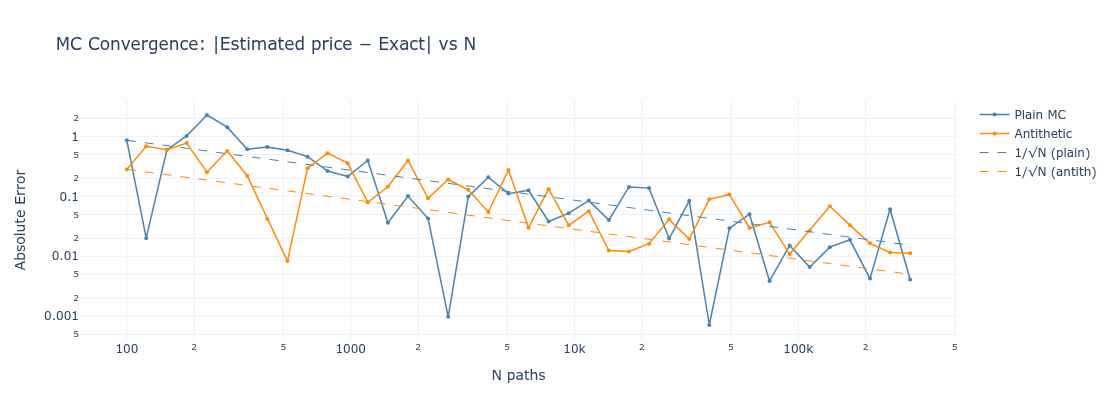

In [6]:
Ns = np.unique(np.logspace(2, 5.5, 40).astype(int))
errors_plain, errors_antith = [], []

rng2 = np.random.default_rng(0)

for N_i in Ns:
    Z   = rng2.standard_normal(N_i)
    S_T = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    p   = np.exp(-r*T) * np.maximum(S_T - K, 0.0).mean()
    errors_plain.append(abs(p - exact_call))

    N2  = max(N_i // 2, 1)
    Z2  = rng2.standard_normal(N2)
    fwd = (r - q - 0.5*sigma**2)*T
    pa  = np.exp(-r*T) * 0.5*(np.maximum(S0*np.exp(fwd+sigma*np.sqrt(T)*Z2)-K,0)
                             + np.maximum(S0*np.exp(fwd-sigma*np.sqrt(T)*Z2)-K,0)).mean()
    errors_antith.append(abs(pa - exact_call))

# 1/sqrt(N) reference lines
N_ref  = np.array([Ns[0], Ns[-1]], dtype=float)
ref_p  = errors_plain[0]  * np.sqrt(Ns[0])  / np.sqrt(N_ref)
ref_a  = errors_antith[0] * np.sqrt(Ns[0]) / np.sqrt(N_ref)

fig = go.Figure()
fig.add_trace(go.Scatter(x=Ns, y=errors_plain, mode='lines+markers',
    name='Plain MC', line=dict(color='steelblue', width=1.5), marker=dict(size=4)))
fig.add_trace(go.Scatter(x=Ns, y=errors_antith, mode='lines+markers',
    name='Antithetic', line=dict(color='darkorange', width=1.5), marker=dict(size=4)))
fig.add_trace(go.Scatter(x=N_ref, y=ref_p, mode='lines',
    name='1/\u221aN (plain)', line=dict(color='steelblue', width=1, dash='dash')))
fig.add_trace(go.Scatter(x=N_ref, y=ref_a, mode='lines',
    name='1/\u221aN (antith)', line=dict(color='darkorange', width=1, dash='dash')))

fig.update_layout(
    title='MC Convergence: |Estimated price \u2212 Exact| vs N',
    xaxis_title='N paths', yaxis_title='Absolute Error',
    xaxis_type='log', yaxis_type='log',
    template='plotly_white', height=420
)
fig.show()

## 3. The Four-Panel Visualization

The option price integral $C = \int \text{payoff}(S_T)\cdot e^{-rT}\cdot f_{\mathbb{Q}}(S_T)\,dS_T$
is built up in four steps:

| Panel | Shows |
|-------|-------|
| **A** | $f_{\mathbb{Q}}(S_T)$ — lognormal density of future price |
| **B** | $e^{-rT}\,f_{\mathbb{Q}}(S_T)$ — discounted (present-value-weighted) density |
| **C** | Payoff $\max(S_T-K,0)$ overlaid on the discounted density |
| **D** | **Contribution curve** $\text{payoff}\times e^{-rT}\,f_{\mathbb{Q}}(S_T)$; its area = $C$ |

The vertical dashed line marks the strike $K$. Scenarios to the left contribute nothing;
scenarios to the right contribute proportionally to their payoff and probability.

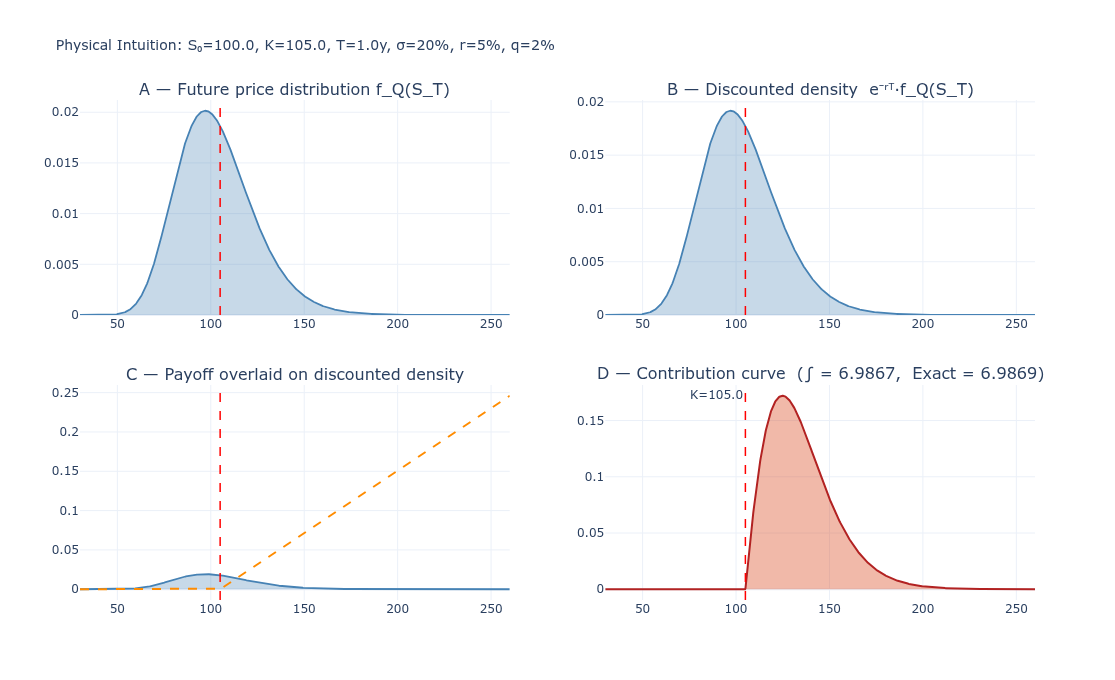


Numerical integral (Panel D area): 6.986748
Exact BS price:                     6.986920
Difference:                         1.72e-04


In [7]:
# Slightly OTM call for a cleaner picture
S0v, Kv, Tv = 100.0, 105.0, 1.0
rv, qv, sigv = 0.05, 0.02, 0.20

exact_v = bs_call(S0v, Kv, Tv, rv, qv, sigv)

# S_T grid
S_grid = np.linspace(30, 260, 1000)

# Lognormal PDF under Q
mu_log   = np.log(S0v) + (rv - qv - 0.5*sigv**2)*Tv
sig_log  = sigv * np.sqrt(Tv)
fQ       = lognorm.pdf(S_grid, s=sig_log, scale=np.exp(mu_log))

# Discounted density
disc     = np.exp(-rv * Tv)
fQ_disc  = disc * fQ

# Call payoff
payoff   = np.maximum(S_grid - Kv, 0.0)

# Contribution curve (Panel D)
contrib  = payoff * fQ_disc
area     = trapz(contrib, S_grid)   # numerical integral ≈ option price

# Scaled payoff for Panel C overlay (different y-scale from density)
payoff_sc = payoff / (Kv * 6)

FILL_A = 'rgba(70,130,180,0.30)'
FILL_B = 'rgba(70,130,180,0.30)'
FILL_D = 'rgba(220,80,40,0.40)'
LINE_BLUE   = dict(color='steelblue',   width=1.8)
LINE_ORANGE = dict(color='darkorange',  width=2.0, dash='dash')
LINE_RED    = dict(color='firebrick',   width=2.0)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'A \u2014 Future price distribution f_Q(S_T)',
        'B \u2014 Discounted density  e\u207b\u02b3\u1d40\u00b7f_Q(S_T)',
        'C \u2014 Payoff overlaid on discounted density',
        f'D \u2014 Contribution curve  (\u222b = {area:.4f},  Exact = {exact_v:.4f})',
    ],
    vertical_spacing=0.14, horizontal_spacing=0.10
)

# ---- Panel A ----
fig.add_trace(go.Scatter(x=S_grid, y=fQ, fill='tozeroy', fillcolor=FILL_A,
    line=LINE_BLUE, showlegend=False, name='f_Q'), row=1, col=1)
fig.add_vline(x=Kv, line_dash='dash', line_color='red', line_width=1.5, row=1, col=1)

# ---- Panel B ----
fig.add_trace(go.Scatter(x=S_grid, y=fQ_disc, fill='tozeroy', fillcolor=FILL_B,
    line=LINE_BLUE, showlegend=False, name='discounted'), row=1, col=2)
fig.add_vline(x=Kv, line_dash='dash', line_color='red', line_width=1.5, row=1, col=2)

# ---- Panel C ----
fig.add_trace(go.Scatter(x=S_grid, y=fQ_disc, fill='tozeroy', fillcolor=FILL_B,
    line=LINE_BLUE, showlegend=False, name='density'), row=2, col=1)
fig.add_trace(go.Scatter(x=S_grid, y=payoff_sc,
    line=LINE_ORANGE, showlegend=False, name='payoff (scaled)'), row=2, col=1)
fig.add_vline(x=Kv, line_dash='dash', line_color='red', line_width=1.5, row=2, col=1)

# ---- Panel D ----
# Shade only the part right of K
mask = S_grid >= Kv
fig.add_trace(go.Scatter(
    x=np.concatenate([[Kv], S_grid[mask], [S_grid[mask][-1]]]),
    y=np.concatenate([[0],  contrib[mask], [0]]),
    fill='toself', fillcolor=FILL_D, line=dict(width=0),
    showlegend=False, name='contrib area'), row=2, col=2)
fig.add_trace(go.Scatter(x=S_grid, y=contrib,
    line=LINE_RED, showlegend=False, name='contribution'), row=2, col=2)
fig.add_vline(x=Kv, line_dash='dash', line_color='red', line_width=1.5,
    annotation_text=f'K={Kv}', annotation_position='top left', row=2, col=2)

fig.update_layout(
    title=dict(text=f'Physical Intuition: S\u2080={S0v}, K={Kv}, T={Tv}y, \u03c3={sigv:.0%}, r={rv:.0%}, q={qv:.0%}',
               font=dict(size=14)),
    template='plotly_white', height=680, showlegend=False
)
fig.show()

print(f'\nNumerical integral (Panel D area): {area:.6f}')
print(f'Exact BS price:                     {exact_v:.6f}')
print(f'Difference:                         {abs(area - exact_v):.2e}')

## 4. Exploring Parameter Effects via Panel D

Each parameter deforms the contribution curve in a characteristic way.

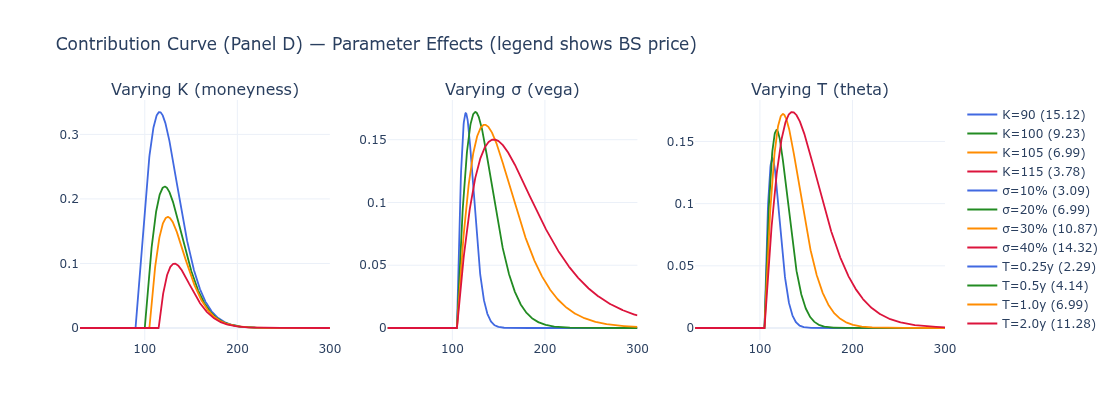

In [8]:
def contribution_curve(S0, K, T, r, q, sigma, S_grid):
    """Compute the contribution curve (Panel D) for given parameters."""
    mu_log  = np.log(S0) + (r - q - 0.5*sigma**2)*T
    sig_log = sigma * np.sqrt(T)
    fQ      = lognorm.pdf(S_grid, s=sig_log, scale=np.exp(mu_log))
    payoff  = np.maximum(S_grid - K, 0.0)
    return payoff * np.exp(-r*T) * fQ

S_grid2 = np.linspace(30, 300, 1000)
base    = dict(S0=100, K=105, T=1.0, r=0.05, q=0.02, sigma=0.20)
colors  = ['royalblue', 'forestgreen', 'darkorange', 'crimson']

fig = make_subplots(1, 3, subplot_titles=[
    'Varying K (moneyness)',
    'Varying \u03c3 (vega)',
    'Varying T (theta)',
])

# Vary K
for K_v, col in zip([90, 100, 105, 115], colors):
    c = contribution_curve(**{**base, 'K': K_v}, S_grid=S_grid2)
    price = trapz(c, S_grid2)
    fig.add_trace(go.Scatter(x=S_grid2, y=c, mode='lines',
        name=f'K={K_v} ({price:.2f})', line=dict(color=col, width=1.8)), row=1, col=1)

# Vary sigma
for sig_v, col in zip([0.10, 0.20, 0.30, 0.40], colors):
    c = contribution_curve(**{**base, 'sigma': sig_v}, S_grid=S_grid2)
    price = trapz(c, S_grid2)
    fig.add_trace(go.Scatter(x=S_grid2, y=c, mode='lines',
        name=f'\u03c3={sig_v:.0%} ({price:.2f})', line=dict(color=col, width=1.8)), row=1, col=2)

# Vary T
for T_v, col in zip([0.25, 0.5, 1.0, 2.0], colors):
    c = contribution_curve(**{**base, 'T': T_v}, S_grid=S_grid2)
    price = trapz(c, S_grid2)
    fig.add_trace(go.Scatter(x=S_grid2, y=c, mode='lines',
        name=f'T={T_v}y ({price:.2f})', line=dict(color=col, width=1.8)), row=1, col=3)

fig.update_layout(
    title='Contribution Curve (Panel D) \u2014 Parameter Effects (legend shows BS price)',
    template='plotly_white', height=420,
    legend=dict(groupclick='toggleitem')
)
fig.show()